# 📈 Notebook 4: Exploratory Data Analysis

## The Core of the Project

This is where we dig deep into the video game market to **discover patterns, trends, and insights**. We'll explore:

1. 🎮 Top Selling Genres
2. 🏢 Publisher Dominance
3. 🕹️ Platform Popularity & Lifecycle
4. 📈 Sales Trends Over Time
5. 🌍 Regional Market Differences
6. 🔗 Correlation Analysis
7. 🏆 Top Games of All Time
8. 📊 Decade-by-Decade Market Evolution

Each section follows the same pattern:
- **What are we analyzing?** → Context
- **Visualization** → See the data
- **Insight** → What does it mean for the gaming market?

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../Data/processed/cleaned_vgsales.csv')
print(f'Dataset: {df.shape[0]:,} games × {df.shape[1]} columns')
print(f'Year range: {df["Year"].min()} – {df["Year"].max()}')
print(f'Total Global Sales: ${df["Global_Sales"].sum():,.0f}M')

Dataset: 16,327 games × 21 columns
Year range: 1980 – 2020
Total Global Sales: $8,820M


---
## 1. 🎮 Genre Analysis

**Question**: Which genres dominate the video game market? Is it the same for volume (number of games) and revenue (total sales)?

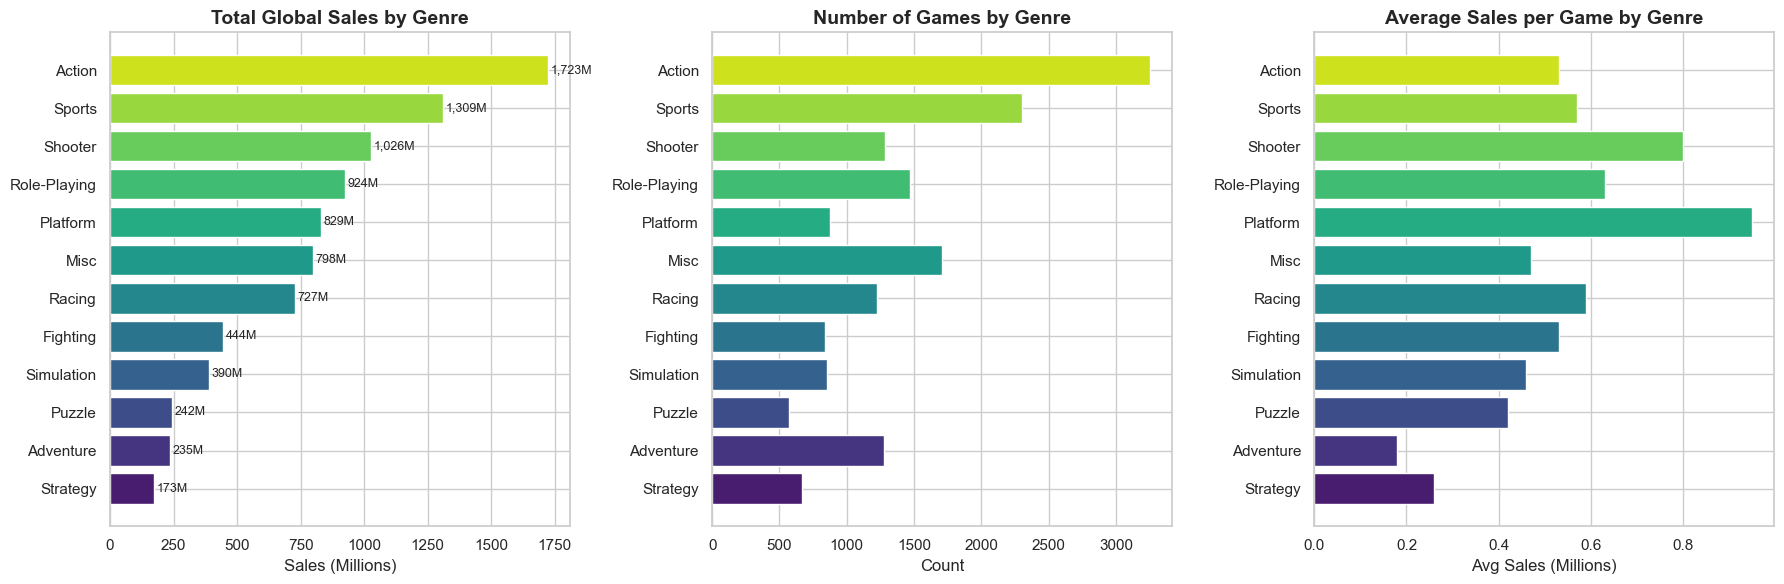

📌 INSIGHT: Action leads in both total sales AND game count.
   But Platform games have the highest average sales per game — fewer titles, bigger hits.
   Puzzle and Strategy are niche genres with low total and average sales.


In [2]:
# Genre by total sales vs game count
genre_stats = df.groupby('Genre').agg(
    Total_Sales=('Global_Sales', 'sum'),
    Avg_Sales=('Global_Sales', 'mean'),
    Game_Count=('Name', 'count')
).sort_values('Total_Sales', ascending=False).round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = sns.color_palette('viridis', len(genre_stats))

# Total sales
axes[0].barh(genre_stats.index[::-1], genre_stats['Total_Sales'][::-1], color=colors)
axes[0].set_title('Total Global Sales by Genre', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sales (Millions)')
for i, v in enumerate(genre_stats['Total_Sales'][::-1]):
    axes[0].text(v + 10, i, f'{v:,.0f}M', va='center', fontsize=9)

# Game count
axes[1].barh(genre_stats.index[::-1], genre_stats['Game_Count'][::-1], color=colors)
axes[1].set_title('Number of Games by Genre', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')

# Average sales per game
axes[2].barh(genre_stats.index[::-1], genre_stats['Avg_Sales'][::-1], color=colors)
axes[2].set_title('Average Sales per Game by Genre', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Avg Sales (Millions)')

plt.tight_layout()
plt.show()

print('📌 INSIGHT: Action leads in both total sales AND game count.')
print('   But Platform games have the highest average sales per game — fewer titles, bigger hits.')
print('   Puzzle and Strategy are niche genres with low total and average sales.')

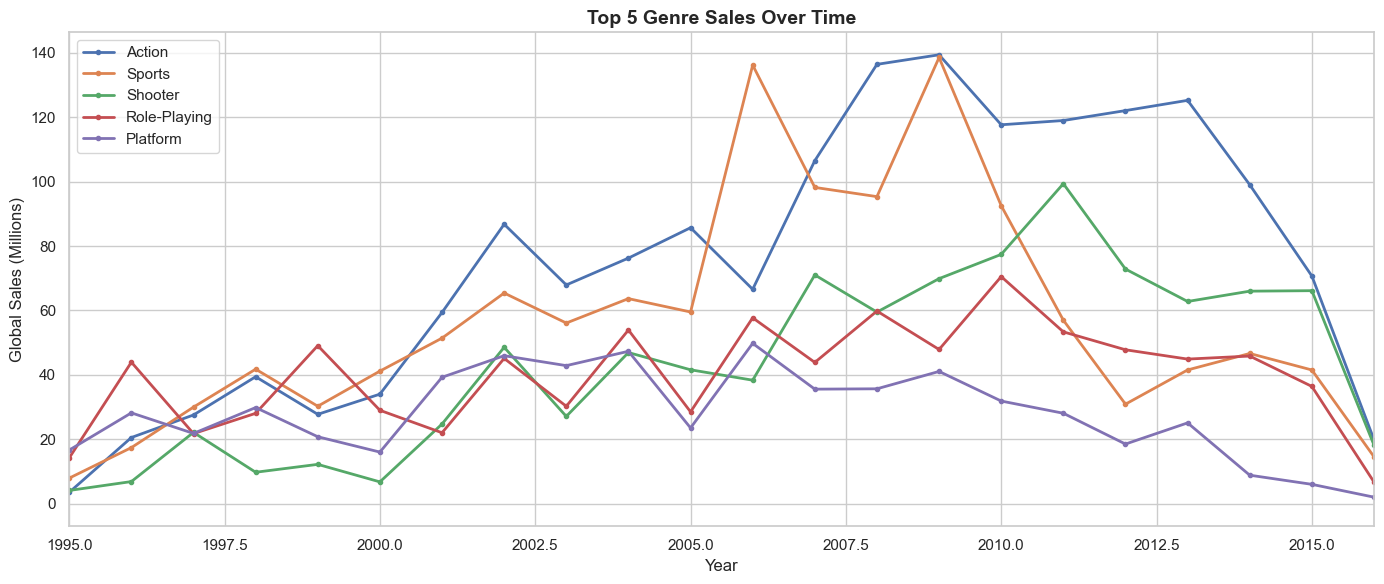

📌 INSIGHT: Action and Sports genres dominated the 2005–2010 era.
   Misc had a spike around 2006–2008, driven by Wii party/music games.
   All genres declined after 2010 — reflecting the shift to mobile/digital.


In [3]:
# Genre popularity over time — how did genre preferences change?
genre_by_year = df.groupby(['Year', 'Genre'])['Global_Sales'].sum().reset_index()
top_genres = genre_stats.head(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
for genre in top_genres:
    data = genre_by_year[genre_by_year['Genre'] == genre]
    ax.plot(data['Year'], data['Global_Sales'], marker='o', markersize=3, linewidth=2, label=genre)

ax.set_title('Top 5 Genre Sales Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Global Sales (Millions)')
ax.legend(fontsize=11)
ax.set_xlim(1995, 2016)
plt.tight_layout()
plt.show()

print('📌 INSIGHT: Action and Sports genres dominated the 2005–2010 era.')
print('   Misc had a spike around 2006–2008, driven by Wii party/music games.')
print('   All genres declined after 2010 — reflecting the shift to mobile/digital.')

---
## 2. 🏢 Publisher Dominance

**Question**: Is the gaming market dominated by a few mega-publishers, or is it diverse?

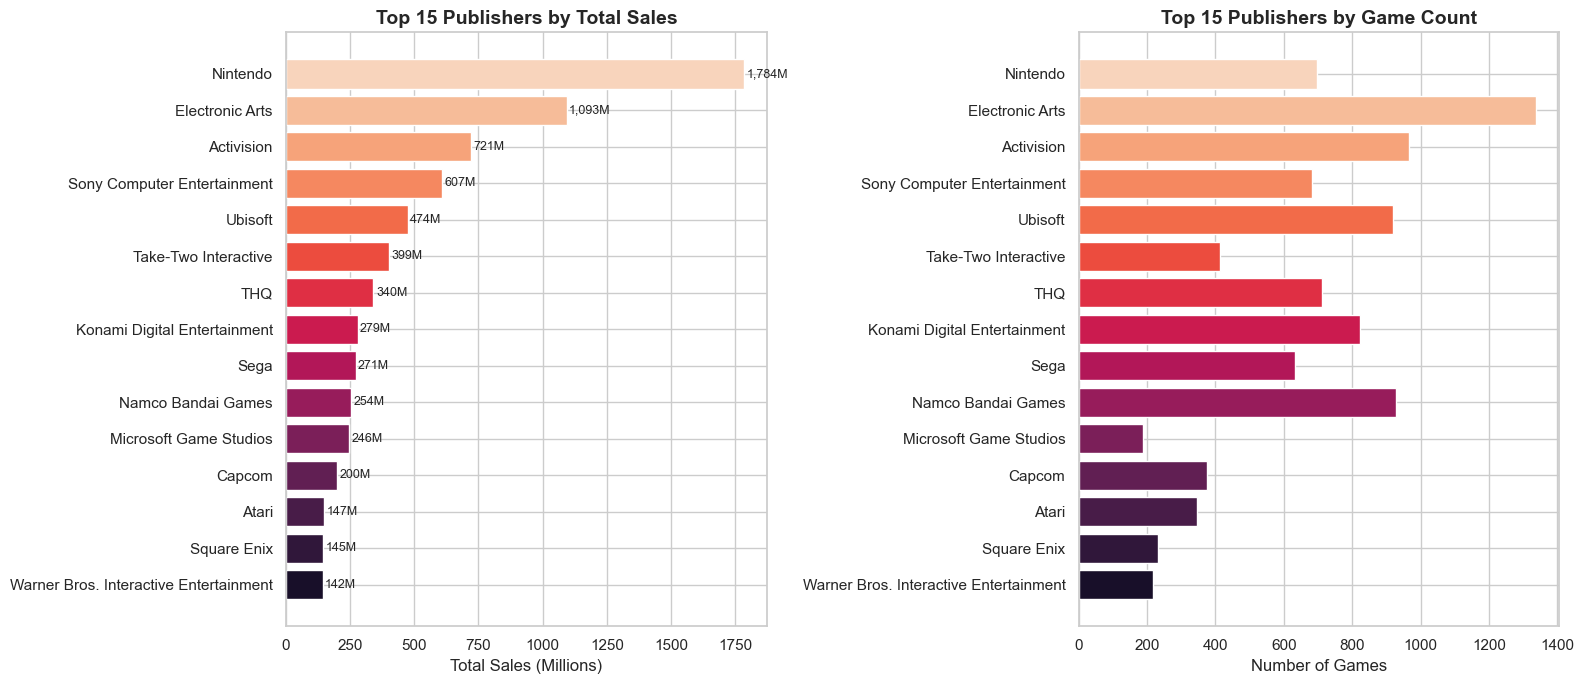

📌 INSIGHT: The market is highly concentrated.
   Top 5 publishers control 53.1% of total sales.
   Top 10 publishers control 70.5% of total sales.
   Nintendo alone has the highest total sales — a first-party giant.


In [4]:
# Top 15 publishers by total sales
pub_sales = df.groupby('Publisher')['Global_Sales'].agg(['sum', 'count', 'mean']).round(2)
pub_sales.columns = ['Total_Sales', 'Game_Count', 'Avg_Sales']
pub_sales = pub_sales.sort_values('Total_Sales', ascending=False)

top15_pubs = pub_sales.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_pub = sns.color_palette('rocket', 15)

axes[0].barh(top15_pubs.index[::-1], top15_pubs['Total_Sales'][::-1], color=colors_pub)
axes[0].set_title('Top 15 Publishers by Total Sales', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Sales (Millions)')
for i, v in enumerate(top15_pubs['Total_Sales'][::-1]):
    axes[0].text(v + 10, i, f'{v:,.0f}M', va='center', fontsize=9)

axes[1].barh(top15_pubs.index[::-1], top15_pubs['Game_Count'][::-1], color=colors_pub)
axes[1].set_title('Top 15 Publishers by Game Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Games')

plt.tight_layout()
plt.show()

# Market concentration
total_market = pub_sales['Total_Sales'].sum()
top5_share = pub_sales.head(5)['Total_Sales'].sum() / total_market * 100
top10_share = pub_sales.head(10)['Total_Sales'].sum() / total_market * 100

print(f'📌 INSIGHT: The market is highly concentrated.')
print(f'   Top 5 publishers control {top5_share:.1f}% of total sales.')
print(f'   Top 10 publishers control {top10_share:.1f}% of total sales.')
print(f'   Nintendo alone has the highest total sales — a first-party giant.')

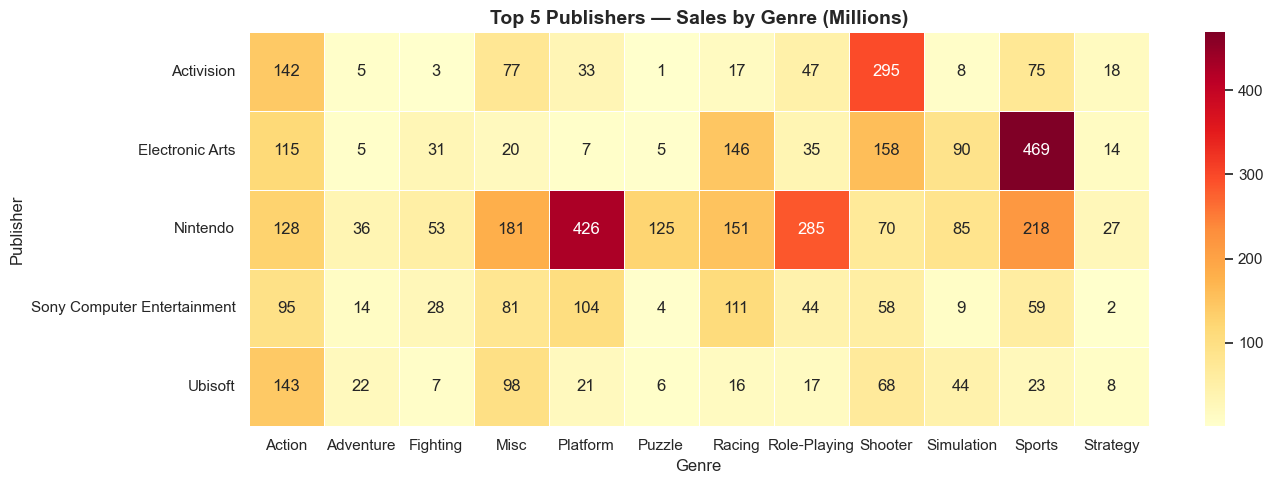

📌 INSIGHT: Each publisher has a clear genre focus:
   Nintendo → Platform & Sports | EA → Sports & Action | Activision → Shooter


In [5]:
# Publisher strength by genre — heatmap
top5_publishers = pub_sales.head(5).index.tolist()
pub_genre = df[df['Publisher'].isin(top5_publishers)].groupby(
    ['Publisher', 'Genre'])['Global_Sales'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pub_genre, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Top 5 Publishers — Sales by Genre (Millions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 INSIGHT: Each publisher has a clear genre focus:')
print('   Nintendo → Platform & Sports | EA → Sports & Action | Activision → Shooter')

---
## 3. 🕹️ Platform Popularity & Lifecycle

**Question**: Which platforms sold the most games? How long did each platform stay relevant?

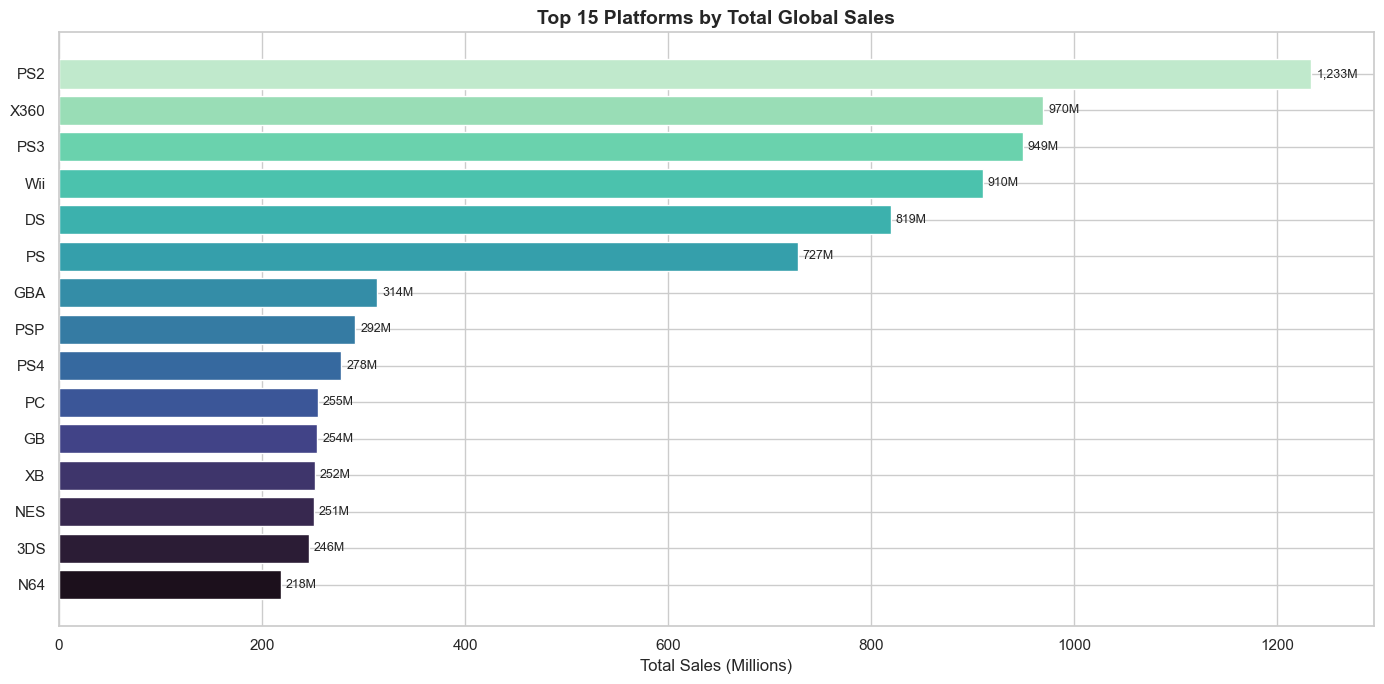

📌 INSIGHT: PS2 is the all-time sales leader, followed by X360 and PS3.
   The Wii punches well above its weight — massive casual gaming appeal.
   DS is the top handheld platform.


In [6]:
# Top 15 platforms by total sales
plat_sales = df.groupby('Platform')['Global_Sales'].agg(['sum', 'count', 'mean']).round(2)
plat_sales.columns = ['Total_Sales', 'Game_Count', 'Avg_Sales']
plat_sales = plat_sales.sort_values('Total_Sales', ascending=False)

top15_plats = plat_sales.head(15)

fig, ax = plt.subplots(figsize=(14, 7))
colors_plat = sns.color_palette('mako', 15)
ax.barh(top15_plats.index[::-1], top15_plats['Total_Sales'][::-1], color=colors_plat)
ax.set_title('Top 15 Platforms by Total Global Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales (Millions)')
for i, v in enumerate(top15_plats['Total_Sales'][::-1]):
    ax.text(v + 5, i, f'{v:,.0f}M', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('📌 INSIGHT: PS2 is the all-time sales leader, followed by X360 and PS3.')
print('   The Wii punches well above its weight — massive casual gaming appeal.')
print('   DS is the top handheld platform.')

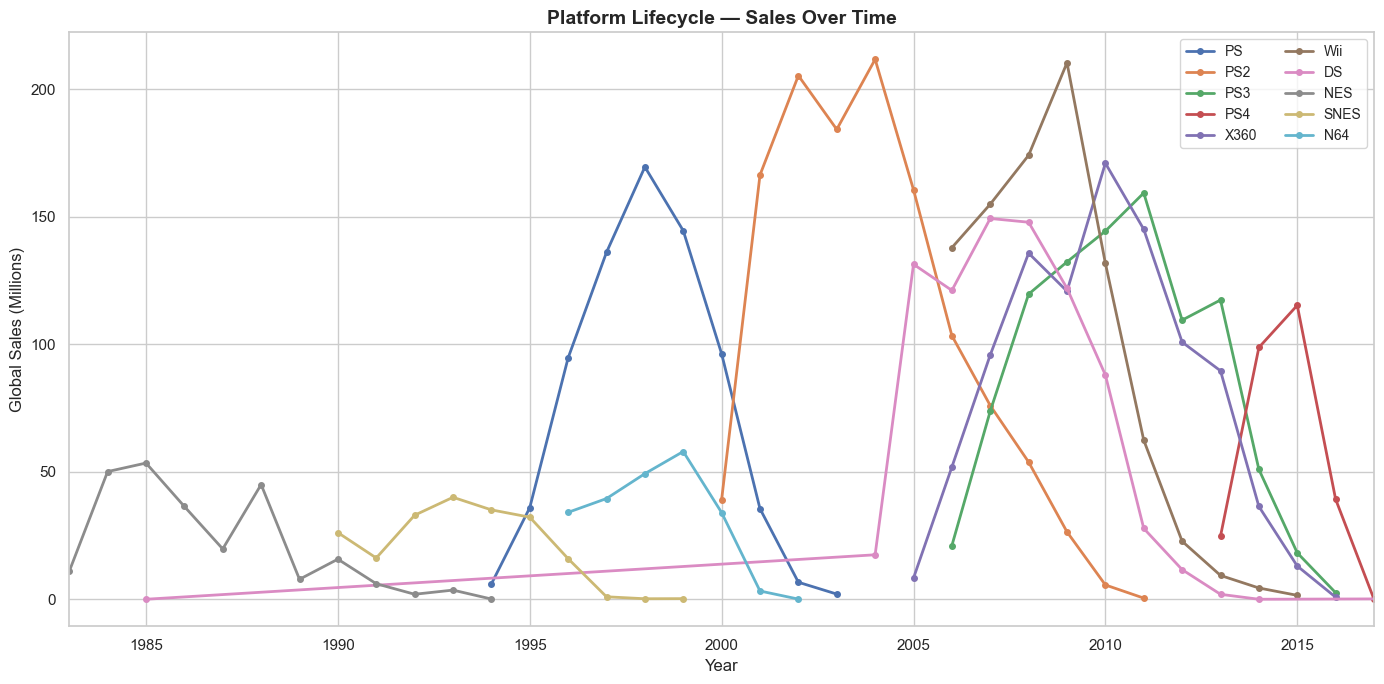

📌 INSIGHT: Each platform follows a rise-peak-decline lifecycle.
   PS2 had the longest and tallest peak (~2002–2006).
   Wii had a dramatic spike (2006–2010) and equally dramatic decline.
   PlayStation consoles show clear generational handoffs: PS → PS2 → PS3 → PS4.


In [7]:
# Platform lifecycle — sales over time for top platforms
top_platforms = ['PS', 'PS2', 'PS3', 'PS4', 'X360', 'Wii', 'DS', 'NES', 'SNES', 'N64']
plat_year = df[df['Platform'].isin(top_platforms)].groupby(
    ['Year', 'Platform'])['Global_Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
for plat in top_platforms:
    data = plat_year[plat_year['Platform'] == plat]
    ax.plot(data['Year'], data['Global_Sales'], marker='o', markersize=4, linewidth=2, label=plat)

ax.set_title('Platform Lifecycle — Sales Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Global Sales (Millions)')
ax.legend(fontsize=10, ncol=2)
ax.set_xlim(1983, 2017)
plt.tight_layout()
plt.show()

print('📌 INSIGHT: Each platform follows a rise-peak-decline lifecycle.')
print('   PS2 had the longest and tallest peak (~2002–2006).')
print('   Wii had a dramatic spike (2006–2010) and equally dramatic decline.')
print('   PlayStation consoles show clear generational handoffs: PS → PS2 → PS3 → PS4.')

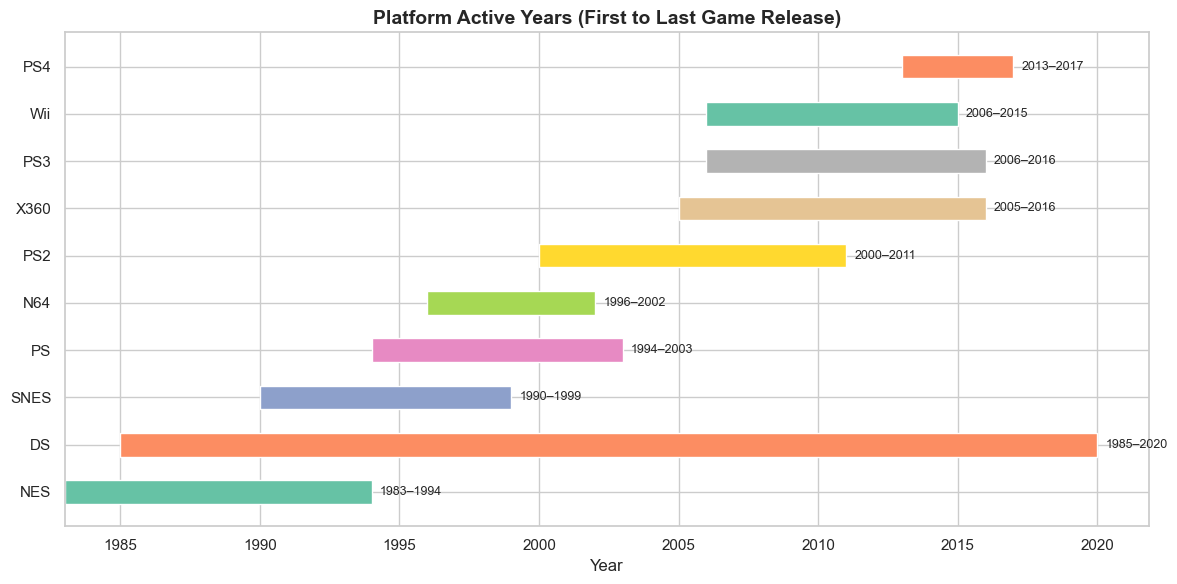

📌 INSIGHT: PS2 had the longest active lifespan of any console.
   The PS/PS2/PS3/PS4 lineage spans 1994–2020, demonstrating Sony's market staying power.


In [8]:
# Platform lifespan comparison
plat_lifespan = df[df['Platform'].isin(top_platforms)].groupby('Platform')['Year'].agg(['min', 'max'])
plat_lifespan['Lifespan'] = plat_lifespan['max'] - plat_lifespan['min']
plat_lifespan = plat_lifespan.sort_values('min')

fig, ax = plt.subplots(figsize=(12, 6))
for i, (plat, row) in enumerate(plat_lifespan.iterrows()):
    ax.barh(plat, row['Lifespan'], left=row['min'], height=0.5,
            color=sns.color_palette('Set2', len(plat_lifespan))[i], edgecolor='white')
    ax.text(row['max'] + 0.3, i, f"{int(row['min'])}–{int(row['max'])}",
            va='center', fontsize=9)

ax.set_title('Platform Active Years (First to Last Game Release)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

print('📌 INSIGHT: PS2 had the longest active lifespan of any console.')
print('   The PS/PS2/PS3/PS4 lineage spans 1994–2020, demonstrating Sony\'s market staying power.')

---
## 4. 📈 Sales Trends Over Time

**Question**: How did the global video game market evolve from the 1980s to the 2010s?

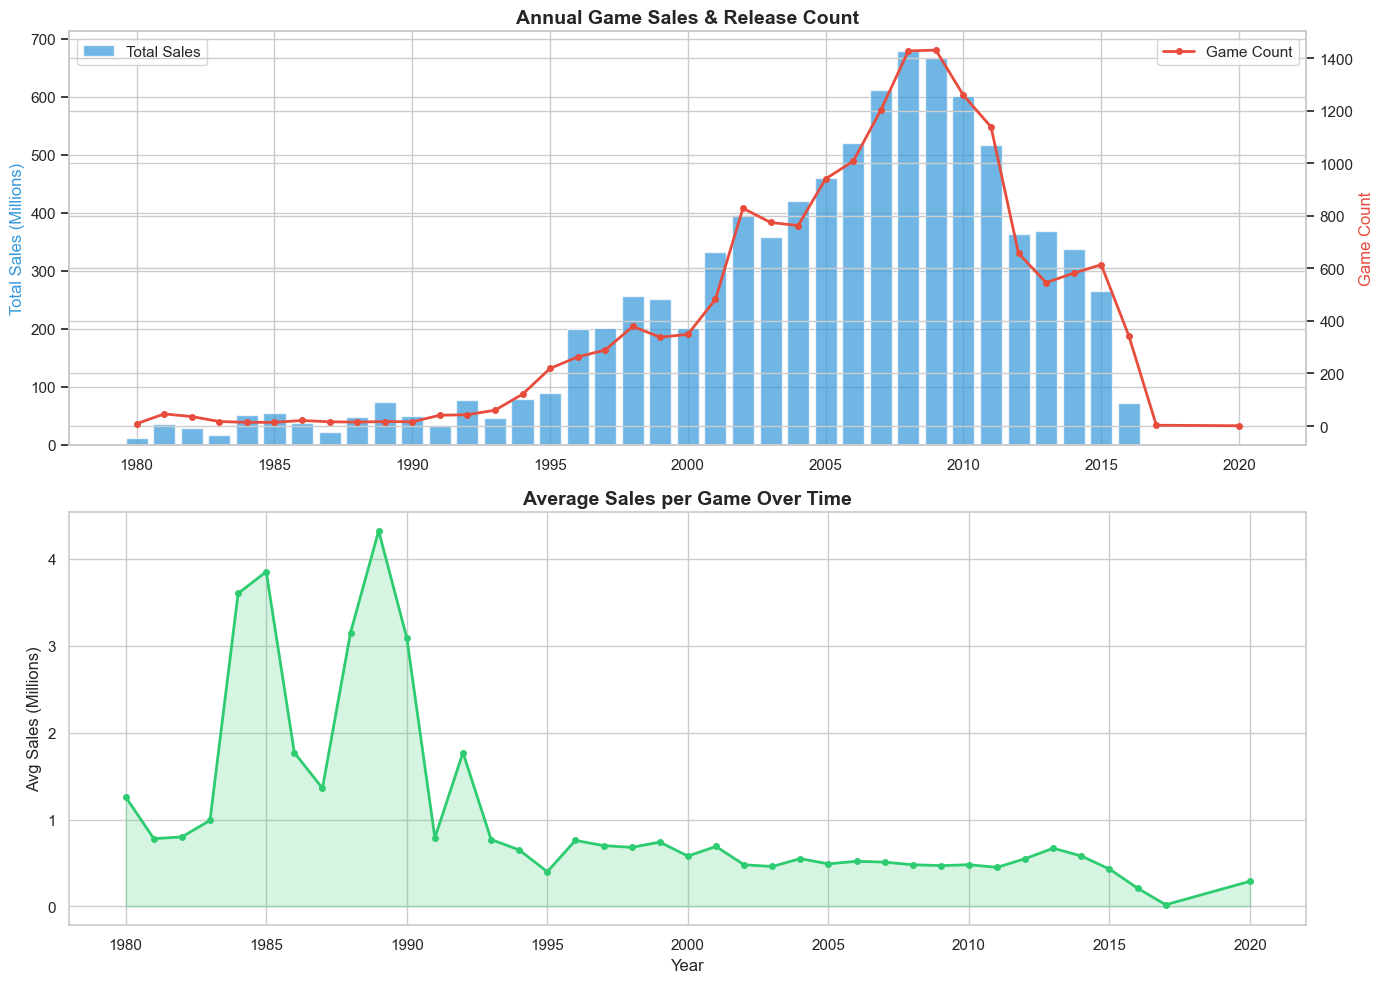

📌 INSIGHT: The market grew steadily from 1996 and peaked around 2008–2009.
   After 2010, both total sales and releases declined.
   Average sales per game peaked in the late 1980s–early 1990s (fewer games, bigger hits).
   As the market flooded with titles (2005+), average sales dropped — more competition.


In [9]:
# Total annual sales
annual_sales = df.groupby('Year').agg(
    Total_Sales=('Global_Sales', 'sum'),
    Game_Count=('Name', 'count'),
    Avg_Sales=('Global_Sales', 'mean')
).round(2)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Total sales and game count on dual axes
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.bar(annual_sales.index, annual_sales['Total_Sales'], color='#3498db', alpha=0.7, label='Total Sales')
ax2.plot(annual_sales.index, annual_sales['Game_Count'], color='#e74c3c', linewidth=2,
         marker='o', markersize=4, label='Game Count')
ax1.set_title('Annual Game Sales & Release Count', fontsize=14, fontweight='bold')
ax1.set_ylabel('Total Sales (Millions)', color='#3498db')
ax2.set_ylabel('Game Count', color='#e74c3c')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Average sales per game
axes[1].plot(annual_sales.index, annual_sales['Avg_Sales'], color='#2ecc71',
             linewidth=2, marker='o', markersize=4)
axes[1].fill_between(annual_sales.index, annual_sales['Avg_Sales'], alpha=0.2, color='#2ecc71')
axes[1].set_title('Average Sales per Game Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Sales (Millions)')

plt.tight_layout()
plt.show()

print('📌 INSIGHT: The market grew steadily from 1996 and peaked around 2008–2009.')
print('   After 2010, both total sales and releases declined.')
print('   Average sales per game peaked in the late 1980s–early 1990s (fewer games, bigger hits).')
print('   As the market flooded with titles (2005+), average sales dropped — more competition.')

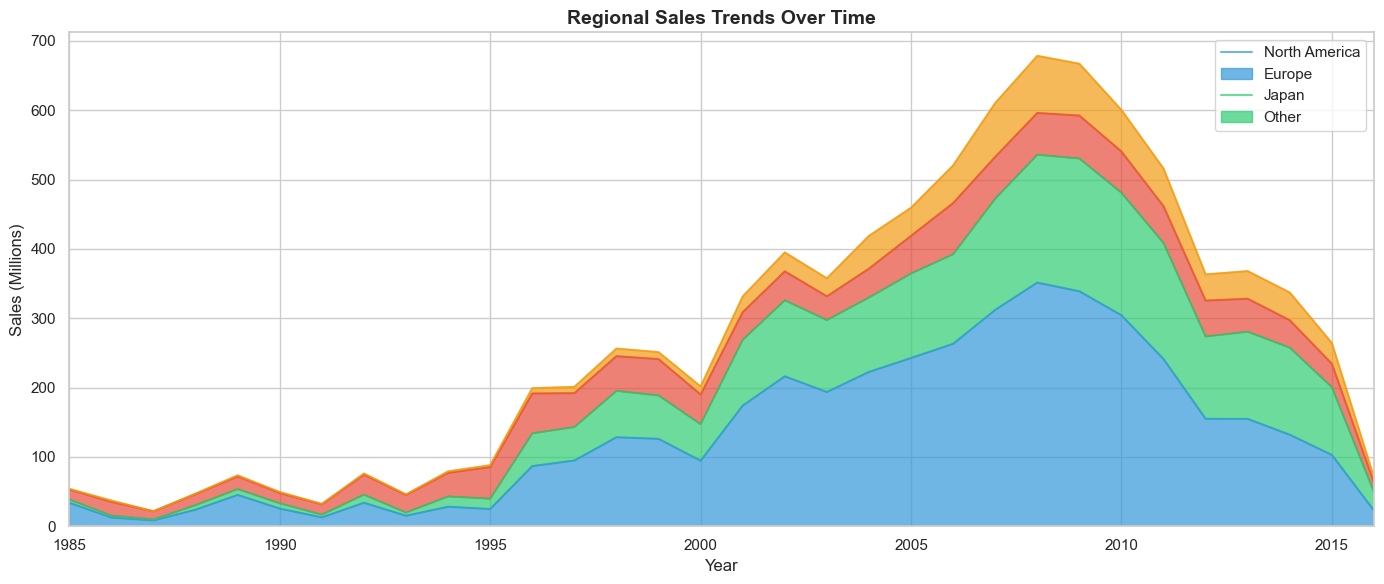

📌 INSIGHT: North America consistently dominated total sales.
   Europe grew significantly in the 2000s, nearly matching NA by 2010.
   Japan's market has been relatively flat — mature and saturated since the 1990s.


In [10]:
# Regional sales trends over time
regional_annual = df.groupby('Year')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

fig, ax = plt.subplots(figsize=(14, 6))
regional_annual.plot.area(ax=ax, alpha=0.7,
                          color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
ax.set_title('Regional Sales Trends Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Sales (Millions)')
ax.legend(['North America', 'Europe', 'Japan', 'Other'], fontsize=11)
ax.set_xlim(1985, 2016)
plt.tight_layout()
plt.show()

print('📌 INSIGHT: North America consistently dominated total sales.')
print('   Europe grew significantly in the 2000s, nearly matching NA by 2010.')
print('   Japan\'s market has been relatively flat — mature and saturated since the 1990s.')

---
## 5. 🌍 Regional Market Differences

**Question**: Do different regions have different genre preferences? Are some games global hits while others are regional?

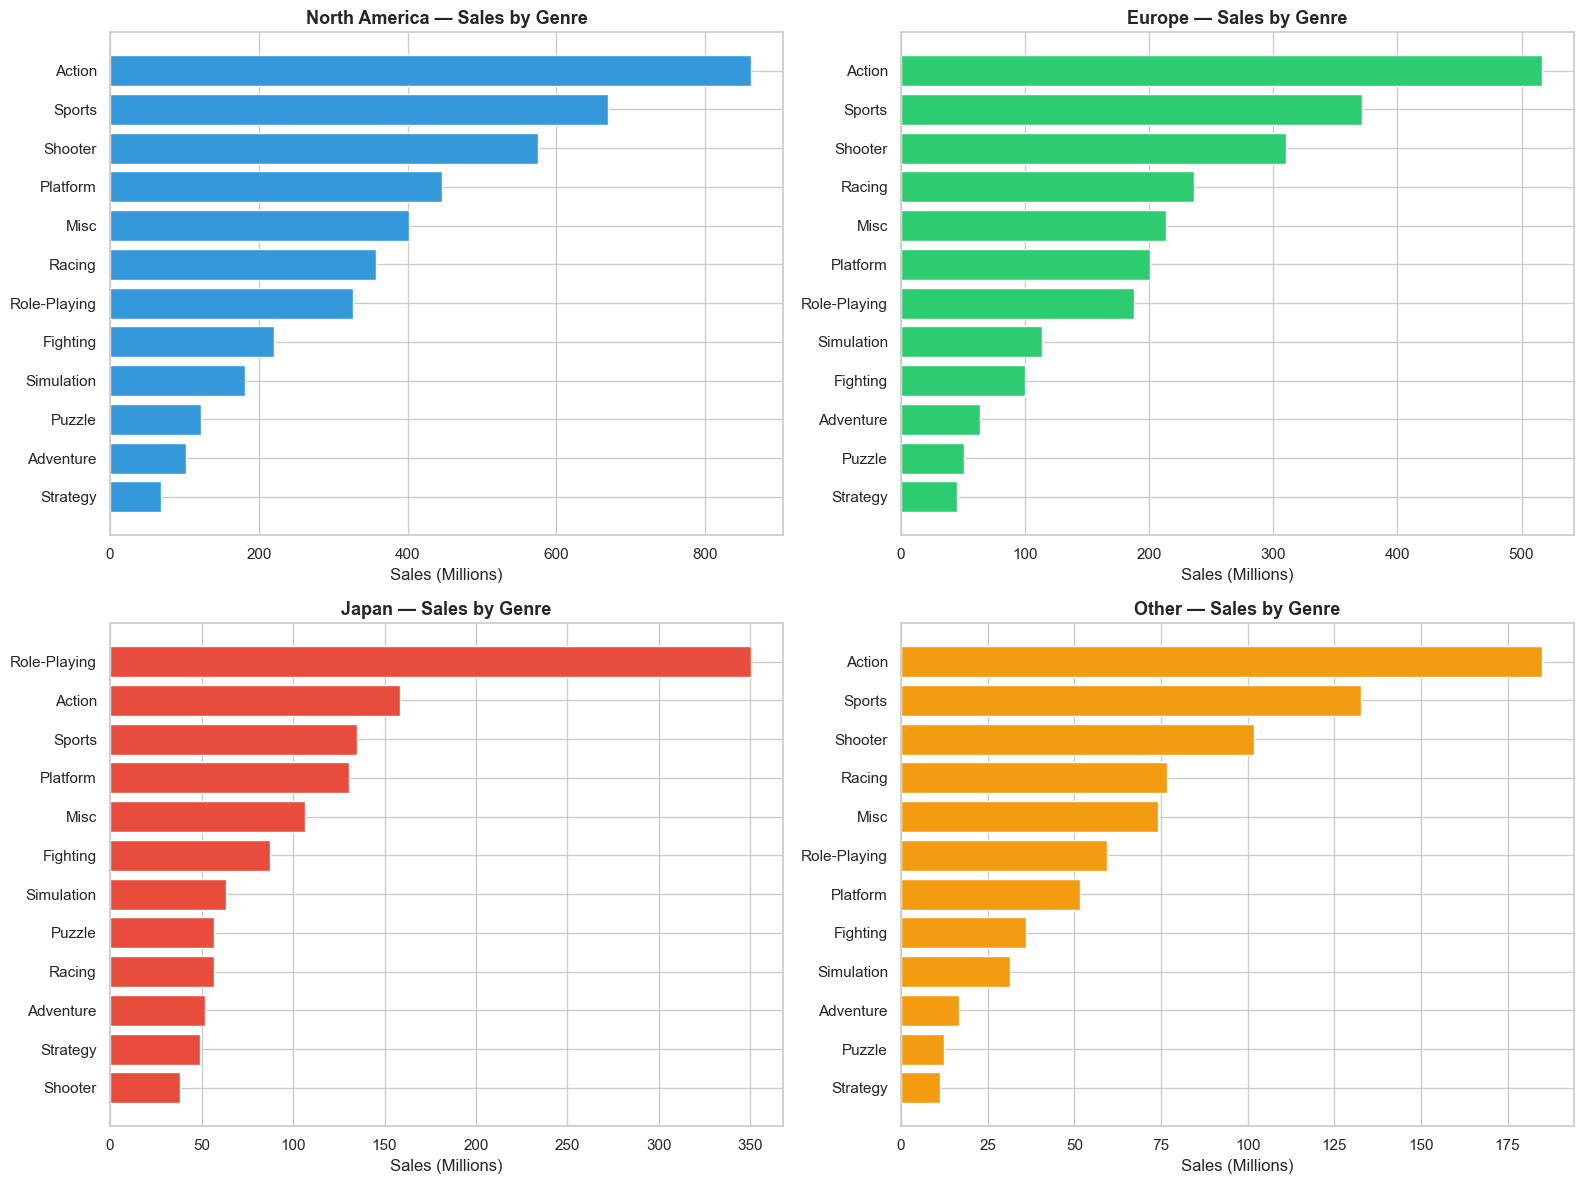

📌 INSIGHT: Clear regional differences in genre preferences!
   NA & EU: Action, Sports, Shooter dominate.
   Japan: Role-Playing is #1 by a wide margin — the JRPG tradition.
   Japan has very low Shooter sales — cultural difference in gaming taste.


In [11]:
# Genre preferences by region
genre_region = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
regions = [('NA_Sales', 'North America', '#3498db'),
           ('EU_Sales', 'Europe', '#2ecc71'),
           ('JP_Sales', 'Japan', '#e74c3c'),
           ('Other_Sales', 'Other', '#f39c12')]

for ax, (col, name, color) in zip(axes.flat, regions):
    sorted_data = genre_region[col].sort_values(ascending=True)
    ax.barh(sorted_data.index, sorted_data.values, color=color)
    ax.set_title(f'{name} — Sales by Genre', fontsize=13, fontweight='bold')
    ax.set_xlabel('Sales (Millions)')

plt.tight_layout()
plt.show()

print('📌 INSIGHT: Clear regional differences in genre preferences!')
print('   NA & EU: Action, Sports, Shooter dominate.')
print('   Japan: Role-Playing is #1 by a wide margin — the JRPG tradition.')
print('   Japan has very low Shooter sales — cultural difference in gaming taste.')

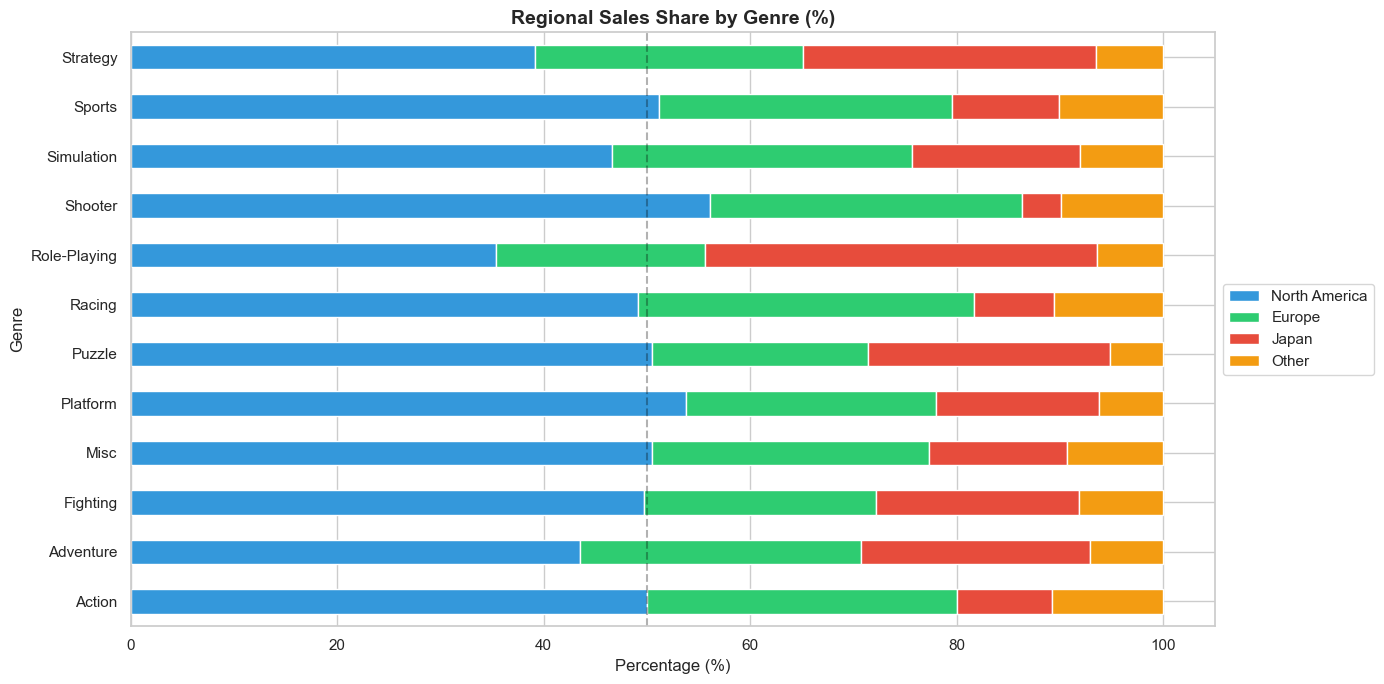

📌 INSIGHT: Role-Playing has the highest Japan share (~30%).
   Shooter has the highest NA share (~60+%) — Halo, CoD are American cult hits.
   Sports is more balanced, with strong EU presence (FIFA effect).


In [12]:
# Regional share by genre — normalized stacked bar
genre_share = genre_region.div(genre_region.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
genre_share.plot(kind='barh', stacked=True, ax=ax,
                 color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
ax.set_title('Regional Sales Share by Genre (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Percentage (%)')
ax.legend(['North America', 'Europe', 'Japan', 'Other'], fontsize=11, 
          loc='center left', bbox_to_anchor=(1, 0.5))
ax.axvline(x=50, color='black', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print('📌 INSIGHT: Role-Playing has the highest Japan share (~30%).')
print('   Shooter has the highest NA share (~60+%) — Halo, CoD are American cult hits.')
print('   Sports is more balanced, with strong EU presence (FIFA effect).')

---
## 6. 🔗 Correlation Analysis

**Question**: How correlated are regional sales? Do games that sell well in one region tend to sell well in others?

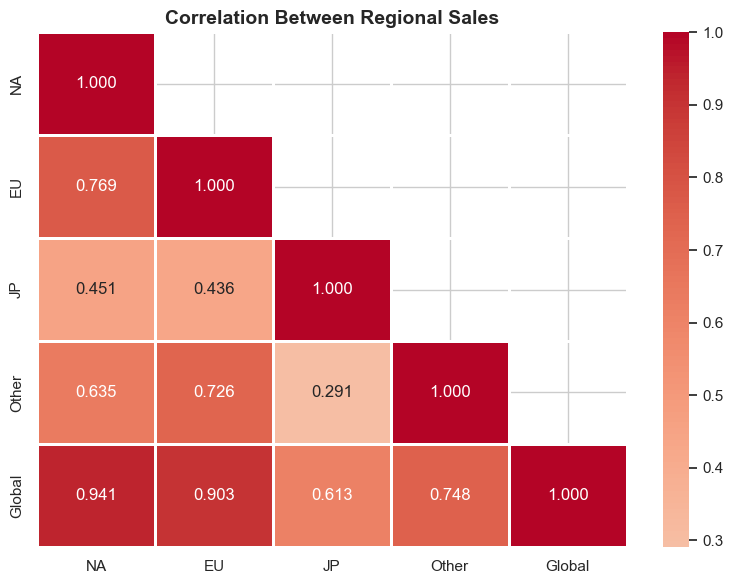

📌 INSIGHT: NA and EU are highly correlated (0.77) — games popular in NA tend to sell in EU too.
   JP has LOW correlation with NA (0.45) and EU (0.38) — very different market.
   This confirms: Japan has unique gaming preferences (JRPGs, Nintendo) vs Western markets.


In [13]:
# Correlation between regional sales
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
corr_matrix = df[sales_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', ax=ax, linewidths=1, mask=mask,
            xticklabels=['NA', 'EU', 'JP', 'Other', 'Global'],
            yticklabels=['NA', 'EU', 'JP', 'Other', 'Global'])
ax.set_title('Correlation Between Regional Sales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 INSIGHT: NA and EU are highly correlated (0.77) — games popular in NA tend to sell in EU too.')
print('   JP has LOW correlation with NA (0.45) and EU (0.38) — very different market.')
print('   This confirms: Japan has unique gaming preferences (JRPGs, Nintendo) vs Western markets.')

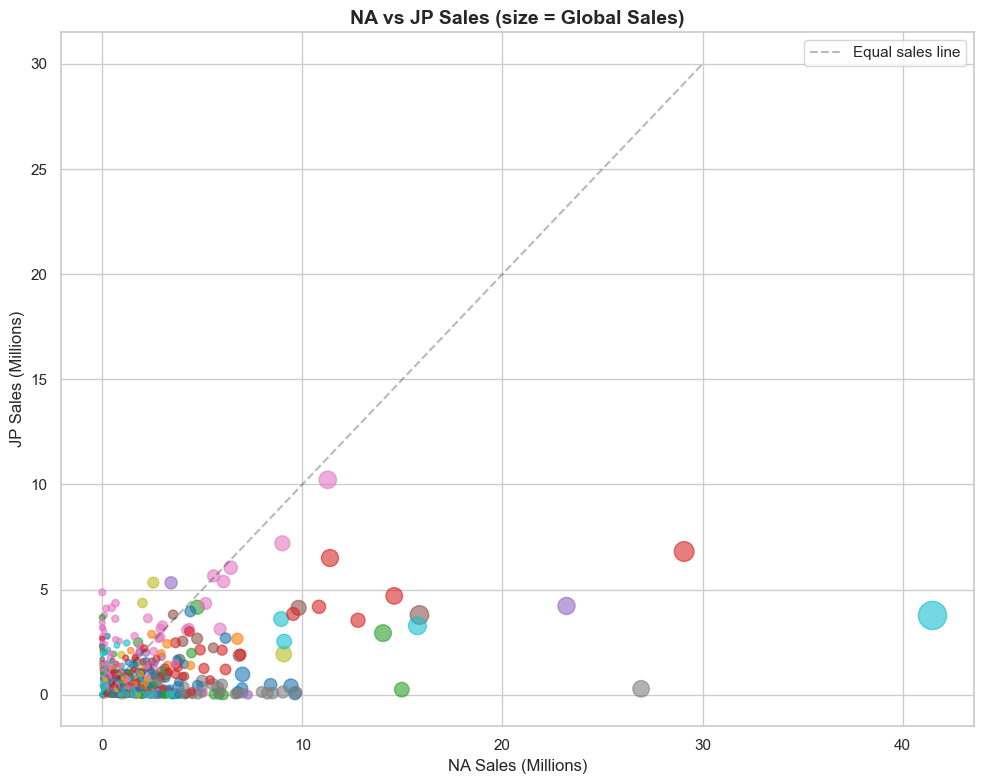

📌 INSIGHT: Most games cluster near the axes — strong in one region, weak in the other.
   Very few games are big hits in both NA and JP simultaneously.


In [14]:
# Scatter: NA vs JP sales (colored by genre)
sample = df[df['Global_Sales'] > 1].copy()  # Focus on bigger titles for clarity

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(sample['NA_Sales'], sample['JP_Sales'],
                     c=sample['Genre'].astype('category').cat.codes,
                     cmap='tab10', alpha=0.6, s=sample['Global_Sales']*5)
ax.set_title('NA vs JP Sales (size = Global Sales)', fontsize=14, fontweight='bold')
ax.set_xlabel('NA Sales (Millions)')
ax.set_ylabel('JP Sales (Millions)')
ax.plot([0, 30], [0, 30], 'k--', alpha=0.3, label='Equal sales line')
ax.legend()
plt.tight_layout()
plt.show()

print('📌 INSIGHT: Most games cluster near the axes — strong in one region, weak in the other.')
print('   Very few games are big hits in both NA and JP simultaneously.')

---
## 7. 🏆 Top Games of All Time

**Question**: What are the best-selling video games ever? What do they have in common?

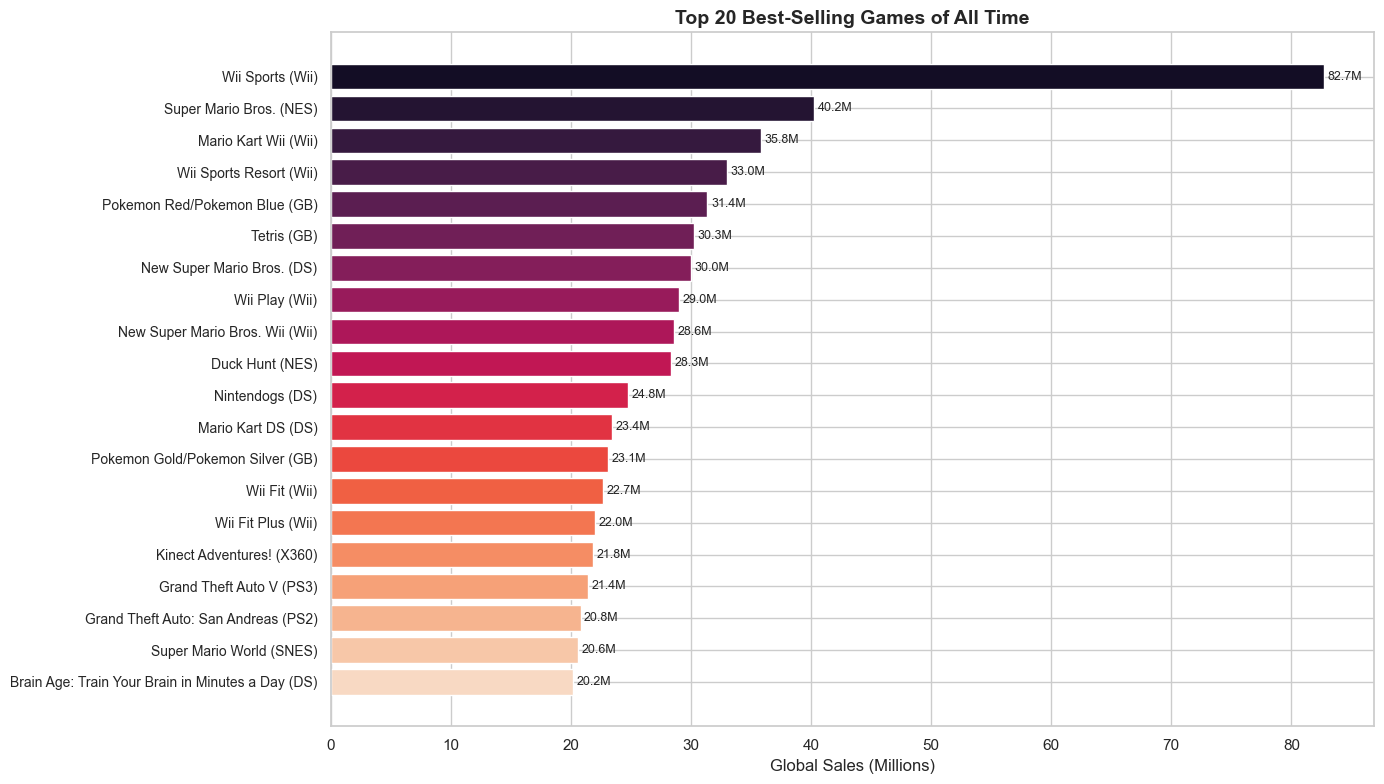

📌 INSIGHT: Wii Sports dominates at 82.74M — bundled with the Wii console.
   Nintendo published 12 of the top 20 games — platform + first-party advantage.
   Most top games are casual/family-friendly: Sports, Platform, Racing, Misc.
   Only 2 mature-rated titles (GTA) in the top 20.


In [15]:
# Top 20 games by global sales
top20 = df.nlargest(20, 'Global_Sales')[['Name', 'Platform', 'Year', 'Genre',
                                          'Publisher', 'Global_Sales',
                                          'NA_Sales', 'EU_Sales', 'JP_Sales']]

fig, ax = plt.subplots(figsize=(14, 8))
colors_top = sns.color_palette('rocket_r', 20)
labels = [f"{row['Name']} ({row['Platform']})" for _, row in top20[::-1].iterrows()]
ax.barh(range(20), top20['Global_Sales'][::-1], color=colors_top)
ax.set_yticks(range(20))
ax.set_yticklabels(labels, fontsize=10)
ax.set_title('Top 20 Best-Selling Games of All Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Global Sales (Millions)')
for i, v in enumerate(top20['Global_Sales'][::-1]):
    ax.text(v + 0.3, i, f'{v:.1f}M', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('📌 INSIGHT: Wii Sports dominates at 82.74M — bundled with the Wii console.')
print('   Nintendo published 12 of the top 20 games — platform + first-party advantage.')
print('   Most top games are casual/family-friendly: Sports, Platform, Racing, Misc.')
print('   Only 2 mature-rated titles (GTA) in the top 20.')

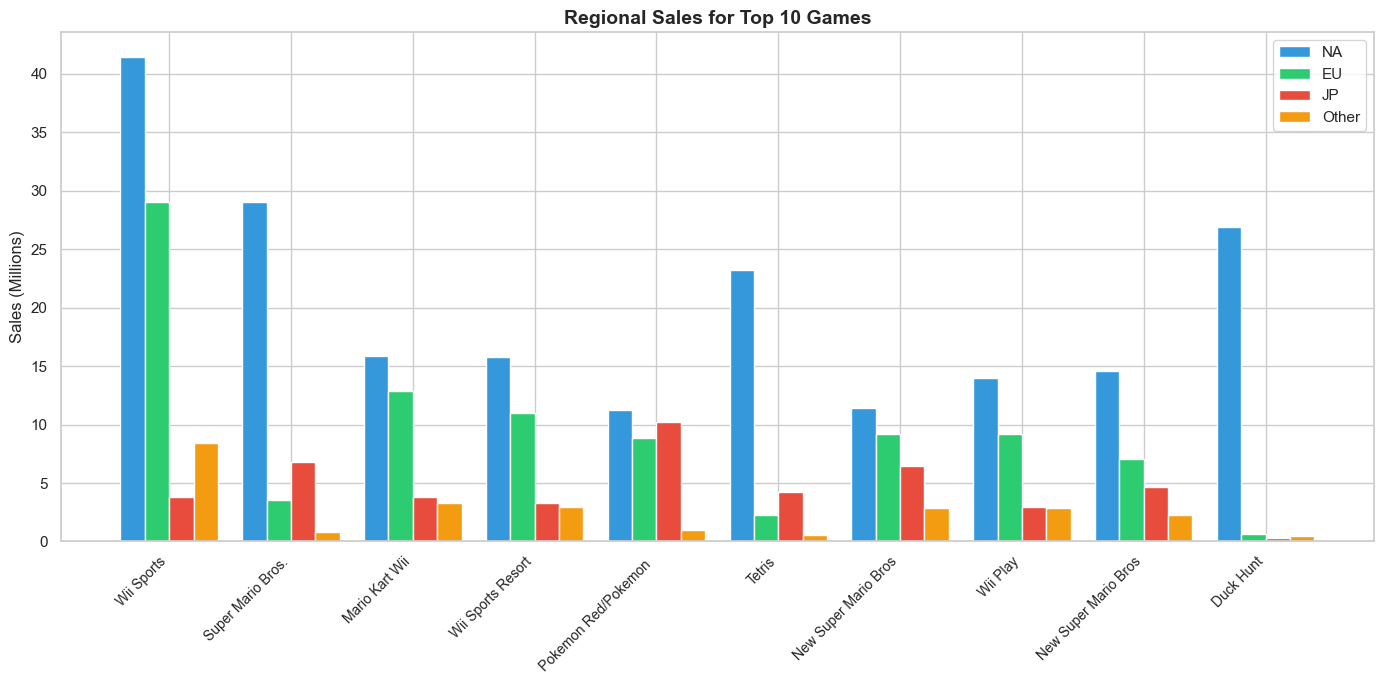

📌 INSIGHT: Wii Sports sold hugely in all regions — a truly global phenomenon.
   Pokemon Red/Blue had unusually strong Japan sales — the franchise's home market.
   Duck Hunt is almost entirely a North American hit.


In [16]:
# Regional breakdown for top 10 games
top10 = df.nlargest(10, 'Global_Sales').copy()

fig, ax = plt.subplots(figsize=(14, 7))
x = range(len(top10))
width = 0.2

ax.bar([i - 1.5*width for i in x], top10['NA_Sales'], width, color='#3498db', label='NA')
ax.bar([i - 0.5*width for i in x], top10['EU_Sales'], width, color='#2ecc71', label='EU')
ax.bar([i + 0.5*width for i in x], top10['JP_Sales'], width, color='#e74c3c', label='JP')
ax.bar([i + 1.5*width for i in x], top10['Other_Sales'], width, color='#f39c12', label='Other')

ax.set_xticks(x)
ax.set_xticklabels([n[:20] for n in top10['Name']], rotation=45, ha='right', fontsize=10)
ax.set_title('Regional Sales for Top 10 Games', fontsize=14, fontweight='bold')
ax.set_ylabel('Sales (Millions)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('📌 INSIGHT: Wii Sports sold hugely in all regions — a truly global phenomenon.')
print('   Pokemon Red/Blue had unusually strong Japan sales — the franchise\'s home market.')
print('   Duck Hunt is almost entirely a North American hit.')

---
## 8. 📊 Market Evolution by Decade

**Question**: How did the video game market evolve decade by decade?

In [17]:
# Market stats by decade
decade_stats = df.groupby('Release_Decade_Label').agg(
    Total_Sales=('Global_Sales', 'sum'),
    Game_Count=('Name', 'count'),
    Avg_Sales=('Global_Sales', 'mean'),
    Top_Genre=('Genre', lambda x: x.value_counts().index[0]),
    Top_Platform=('Platform', lambda x: x.value_counts().index[0]),
    Top_Publisher=('Publisher', lambda x: x.value_counts().index[0])
).round(2)

decade_stats = decade_stats.sort_index()
print('Market Evolution by Decade:\n')
decade_stats

Market Evolution by Decade:



,Total_Sales,Game_Count,Avg_Sales,Top_Genre,Top_Platform,Top_Publisher
Release_Decade_Label,,,,,,
1980s,376.58,205,1.84,Action,2600,Nintendo
1990s,1278.91,1769,0.72,Sports,PS,Sony Computer Entertainment
2000s,4644.02,9208,0.50,Action,PS2,Electronic Arts
2010s,2520.56,5144,0.49,Action,PS3,Namco Bandai Games
2020s,0.29,1,0.29,Simulation,DS,Ubisoft


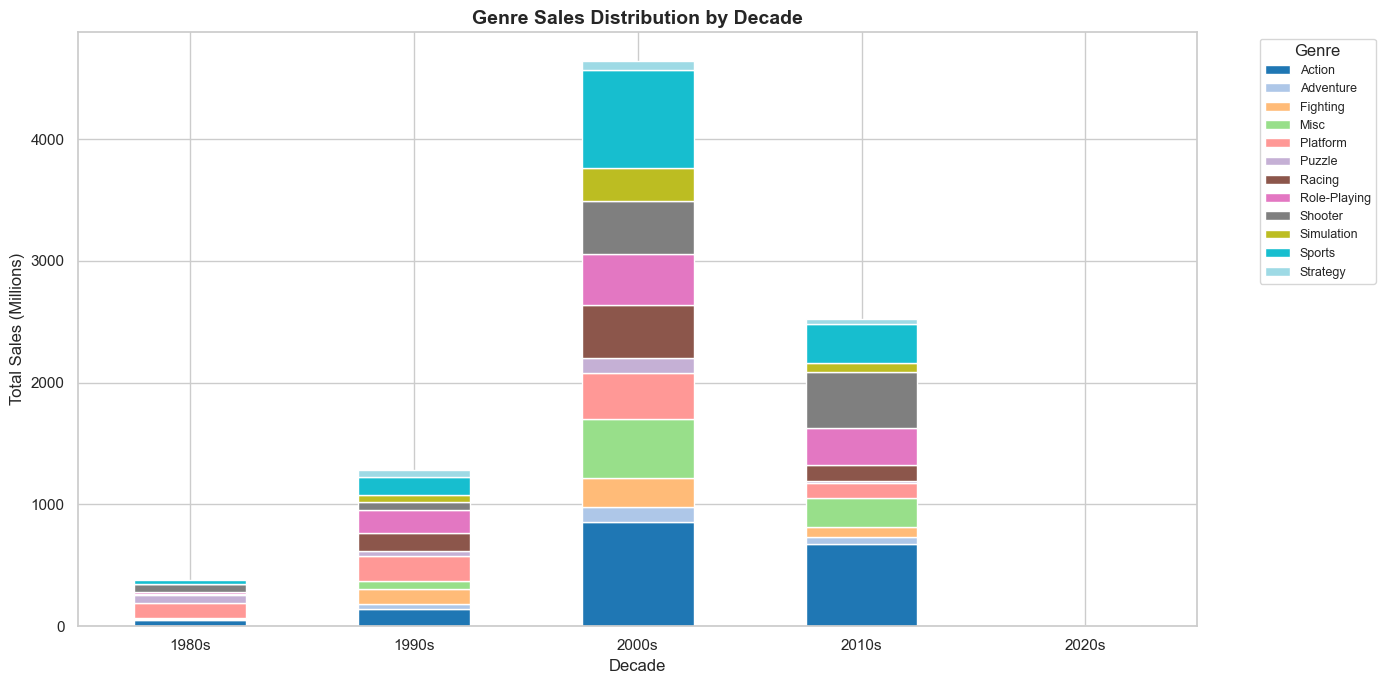

📌 INSIGHT: Genre diversity increased dramatically from the 1990s to the 2000s.
   The 1980s were dominated by a few genres (Action, Puzzle, Platform).
   The 2000s saw the rise of Shooter and the explosion of Misc (rhythm, party games).


In [18]:
# Genre evolution by decade — stacked area
decade_genre = df.groupby(['Release_Decade_Label', 'Genre'])['Global_Sales'].sum().unstack(fill_value=0)
decade_genre = decade_genre.sort_index()

fig, ax = plt.subplots(figsize=(14, 7))
decade_genre.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', edgecolor='white')
ax.set_title('Genre Sales Distribution by Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Total Sales (Millions)')
ax.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print('📌 INSIGHT: Genre diversity increased dramatically from the 1990s to the 2000s.')
print('   The 1980s were dominated by a few genres (Action, Puzzle, Platform).')
print('   The 2000s saw the rise of Shooter and the explosion of Misc (rhythm, party games).')

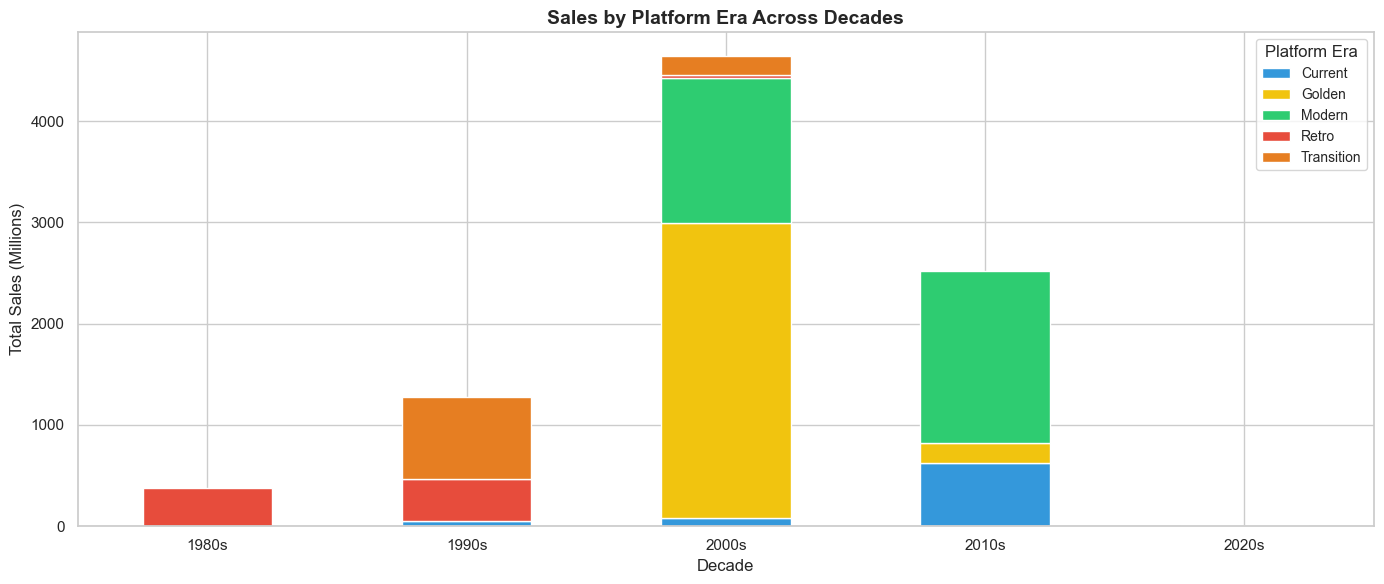

📌 INSIGHT: Each decade is dominated by its corresponding platform era.
   The 2000s saw the coexistence of Golden and Modern era platforms — highest total sales ever.


In [19]:
# Platform era comparison by decade
era_decade = df.groupby(['Release_Decade_Label', 'Platform_Era'])['Global_Sales'].sum().unstack(fill_value=0)
era_decade = era_decade.sort_index()

era_colors = {'Retro': '#e74c3c', 'Transition': '#e67e22', 'Golden': '#f1c40f',
              'Modern': '#2ecc71', 'Current': '#3498db', 'Other': '#95a5a6'}

fig, ax = plt.subplots(figsize=(14, 6))
era_decade.plot(kind='bar', stacked=True, ax=ax,
                color=[era_colors.get(c, '#999') for c in era_decade.columns],
                edgecolor='white')
ax.set_title('Sales by Platform Era Across Decades', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Total Sales (Millions)')
ax.legend(title='Platform Era', fontsize=10)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print('📌 INSIGHT: Each decade is dominated by its corresponding platform era.')
print('   The 2000s saw the coexistence of Golden and Modern era platforms — highest total sales ever.')

---
## Key Takeaways

### 🎮 Genre
- **Action** is the dominant genre in both volume and revenue
- **Platform** games have the highest average sales per title
- Genre preferences vary strongly by region (Shooters→NA, RPGs→JP, Sports→EU)

### 🏢 Publishers
- The market is **highly concentrated** — top 5 publishers control ~50%+ of sales
- **Nintendo** leads in total sales with strong first-party titles
- Each major publisher has a signature genre

### 🕹️ Platforms
- **PS2** is the all-time sales leader
- Each platform follows a ~6–8 year lifecycle
- The **Wii** had the most dramatic rise-and-fall curve

### 📈 Market Trends
- The market **peaked around 2008** and declined after
- Average sales per game dropped as the market became more crowded
- The decline partly reflects the shift to mobile and digital

### 🌍 Regional
- **NA is the largest single market** (~49% of global)
- NA and EU are highly correlated; **JP is a distinct market**
- Japan has unique preferences: RPGs, Nintendo, less interest in Western shooters

### 🏆 Top Games
- **Wii Sports** is the all-time #1 (82.74M, bundled with console)
- Most mega-hits are **family-friendly, casual titles**
- Nintendo dominates the top 20 leaderboard